In [42]:
# Importaciones y utilidades (convergencia primero)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PI = np.pi

def phi(n, x):
    return np.sqrt(2/PI) * np.sin(n * x)

def P_single_n(n, x):
    return phi(n, x) ** 2

def _Pth_partial_cumsums(x, t, Nmax):
    n = np.arange(1, Nmax + 1)[:, None]
    phi2 = (2/PI) * (np.sin(n * x[None, :]) ** 2)
    w = np.exp(-(n[:, 0] ** 2) / t)[:, None]
    num_cum = np.cumsum(w * phi2, axis=0)
    den_cum = np.cumsum(w, axis=0)
    return num_cum / den_cum

def find_N_converged_for_t(t, eps=1e-4, Nmax=600, grid=600, steady_steps=3):
    x = np.linspace(0, PI, grid)
    P_cum = _Pth_partial_cumsums(x, t, Nmax)
    deltas = np.max(np.abs(P_cum[1:] - P_cum[:-1]), axis=1)
    for k in range(steady_steps - 1, deltas.shape[0]):
        window = deltas[k - (steady_steps - 1):k + 1]
        if np.all(window < eps):
            return k + 1
    return Nmax

_N_CACHE = {}

def choose_nmax(t, eps=1e-4):
    # Selecciona N por convergencia y lo cachea para reuso
    t_key = float(t)
    if t_key not in _N_CACHE:
        _N_CACHE[t_key] = find_N_converged_for_t(t_key, eps=eps)
    return _N_CACHE[t_key]

def Pth_single(x, t, nmax=None):
    if nmax is None:
        nmax = choose_nmax(t)
    n = np.arange(1, nmax + 1)[:, None]
    phi2 = (2/PI) * (np.sin(n * x[None, :]) ** 2)
    weights = np.exp(-(n[:, 0] ** 2) / t)[:, None]
    num = np.sum(weights * phi2, axis=0)
    den = np.sum(weights)
    return num / den

def find_boundary_width(t, target=0.1, nmax=None, grid=600):
    if nmax is None:
        nmax = choose_nmax(t)
    xs = np.linspace(0, PI, grid)
    P = Pth_single(xs, t, nmax=nmax)
    idx = np.argmax(P >= target)
    return xs[idx]

## Convergencia de $P_{\rm th}(x,t)$ respecto a $N$
Partimos midiendo cuántos términos de la suma son necesarios para estabilizar $P_{\rm th}$ en cada temperatura adimensional $I$. Usaremos el criterio $\max_x |P_N-P_{N-1}| < 10^{-4}$ sostenido 3 pasos y guardaremos la curva $I \mapsto N$ para reutilizarla en todas las figuras.

t: [1, 10, 30, 50, 80, 100, 150, 200, 250, 300]
N_convergente: [5, 10, 16, 20, 24, 27, 32, 36, 40, 43]


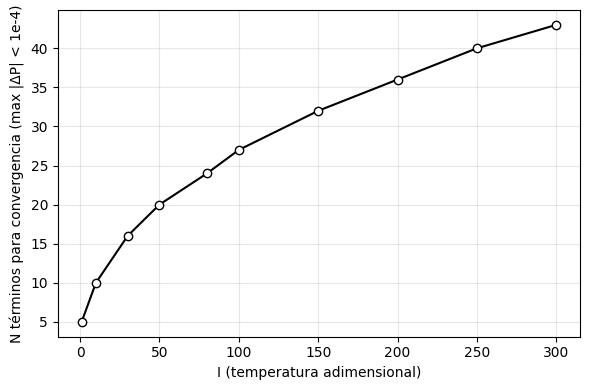

In [43]:
# Cálculo de N(I) por convergencia y gráfica t vs N
ts_conv = [1, 10, 30, 50, 80, 100, 150, 200, 250, 300]
Ns = [choose_nmax(t) for t in ts_conv]
print("t:", ts_conv)
print("N_convergente:", Ns)

plt.figure(figsize=(6,4))
plt.plot(ts_conv, Ns, 'o-k', mfc='white', mec='k')
plt.xlabel('I (temperatura adimensional)')
plt.ylabel('N términos para convergencia (max |ΔP| < 1e-4)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/convergence_t_vs_N.png', dpi=160)
plt.show()

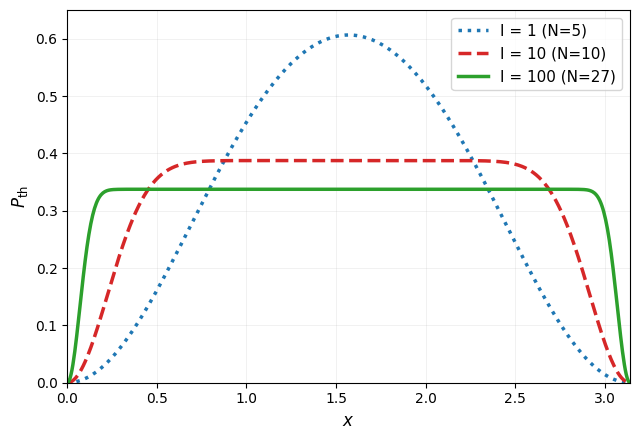

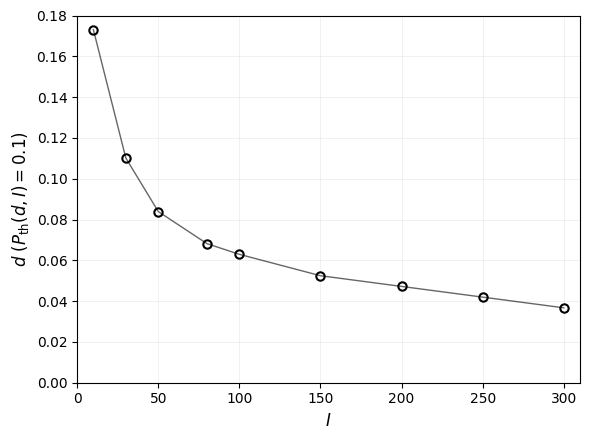

In [44]:
# Figura 1: P_th(x,t) y d(t) usando N adaptativo por convergencia
x = np.linspace(0, PI, 600)

# Figura 1(a): P_th curves con N(t) convergente
fig1a, ax = plt.subplots(figsize=(6.5, 4.5))
for t, color, style, lw, label in [(1, 'C0', ':', 2.5, 'I = 1'),
                                     (10, 'C3', '--', 2.5, 'I = 10'),
                                     (100, 'C2', '-', 2.5, 'I = 100')]:
    n_use = choose_nmax(t)
    P = Pth_single(x, t, nmax=n_use)
    ax.plot(x, P, color=color, linestyle=style, linewidth=lw, label=f"{label} (N={n_use})")

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$P_{\\rm th}$', fontsize=12)
ax.set_xlim(0, PI)
ax.set_ylim(0, 0.65)
ax.legend(loc='upper right', fontsize=11, frameon=True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

# Figura 1(b): boundary layer width d(t) con N adaptativo
ts = [10, 30, 50, 80, 100, 150, 200, 250, 300]
ds = []
for t in ts:
    n_use = choose_nmax(t)
    ds.append(find_boundary_width(t, nmax=n_use, grid=600))

fig1b, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ts, ds, 'ko', markersize=6, markerfacecolor='white', markeredgewidth=1.5)
ax.plot(ts, ds, 'k-', linewidth=1, alpha=0.6)
ax.set_xlabel('$I$', fontsize=12)
ax.set_ylabel('$d$ ($P_{\\rm th}(d, I)=0.1$)', fontsize=12)
ax.set_xlim(0, 310)
ax.set_ylim(0, 0.18)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## Dos partículas sin espín
- Bosones: P^b_{n1,n2}(x1,x2) = (ϕ_{n1}(x1)ϕ_{n2}(x2) + ϕ_{n1}(x2)ϕ_{n2}(x1))^2
- Fermiones: P^f_{n1,n2}(x1,x2) = (ϕ_{n1}(x1)ϕ_{n2}(x2) − ϕ_{n1}(x2)ϕ_{n2}(x1))^2

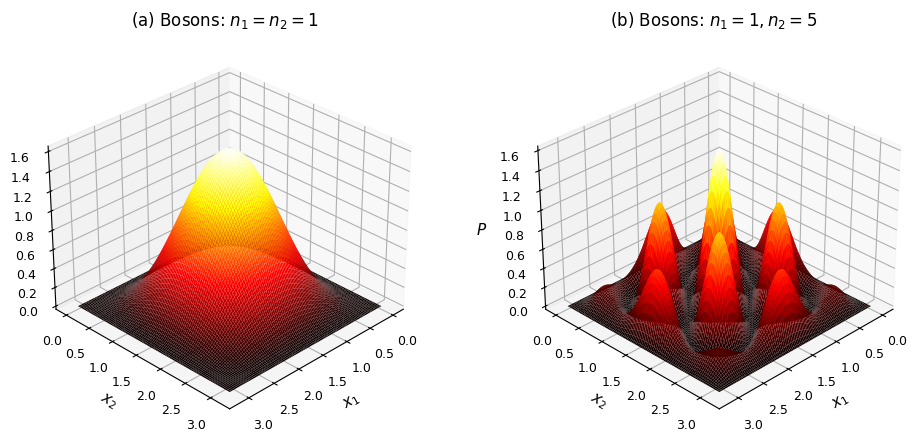

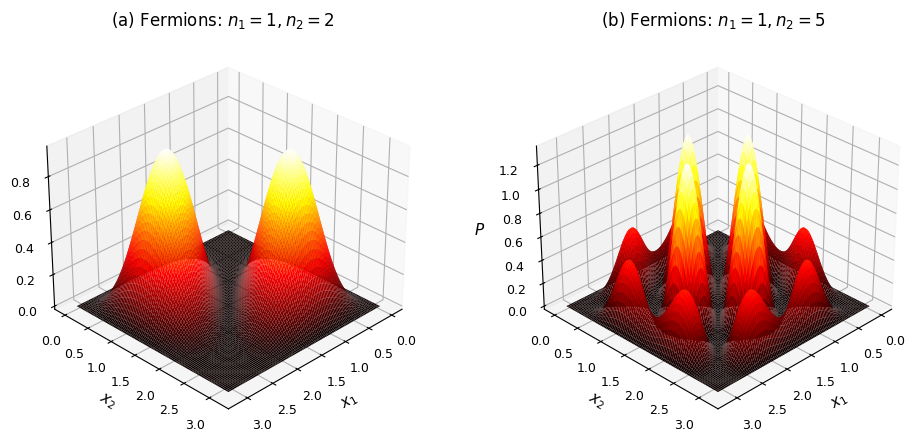

In [45]:
def P2_bosons(n1, n2, X1, X2):
    f = phi(n1, X1) * phi(n2, X2) + phi(n1, X2) * phi(n2, X1)
    return f**2

def P2_fermions(n1, n2, X1, X2):
    f = phi(n1, X1) * phi(n2, X2) - phi(n1, X2) * phi(n2, X1)
    return f**2

x1 = np.linspace(0, PI, 100); x2 = np.linspace(0, PI, 100)
X1, X2 = np.meshgrid(x1, x2)

# Figura 2: Bosones (n1=n2=1) y (n1=1, n2=5)
fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
Z = P2_bosons(1, 1, X1, X2)
surf = ax.plot_surface(X1, X2, Z, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11); ax.set_zlabel('$P$', fontsize=11)
ax.set_title('(a) Bosons: $n_1=n_2=1$', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
Z2 = P2_bosons(1, 5, X1, X2)
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax2.set_xlabel('$x_1$', fontsize=11); ax2.set_ylabel('$x_2$', fontsize=11); ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title('(b) Bosons: $n_1=1, n_2=5$', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

# Figura 3: Fermiones (n1=1, n2=2) y (n1=1, n2=5)
fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
Z = P2_fermions(1, 2, X1, X2)
surf = ax.plot_surface(X1, X2, Z, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11); ax.set_zlabel('$P$', fontsize=11)
ax.set_title('(a) Fermions: $n_1=1, n_2=2$', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
Z2 = P2_fermions(1, 5, X1, X2)
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax2.set_xlabel('$x_1$', fontsize=11); ax2.set_ylabel('$x_2$', fontsize=11); ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title('(b) Fermions: $n_1=1, n_2=5$', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## Densidad térmica para dos partículas
Bosones: sumamos todas las parejas (n1,n2). Fermiones sin espín: usamos n1 < n2.
Fermiones con espín 1/2: P = (1/4)·P_b + (3/4)·P_f y luego termalizamos.

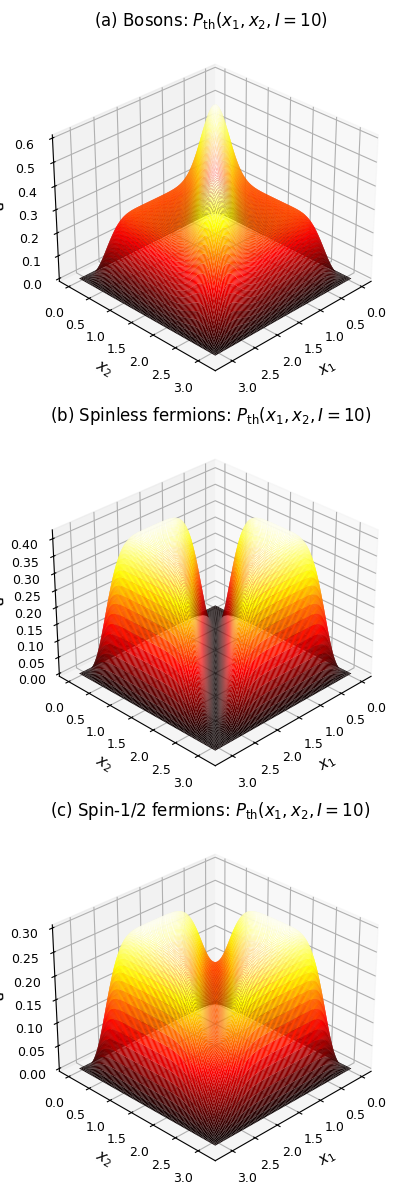

In [46]:
def Pth_two_bosons(X1, X2, t, nmax=None):
    if nmax is None: nmax = choose_nmax(t)
    Z = np.zeros_like(X1); den = 0.0
    for n1 in range(1, nmax+1):
        for n2 in range(1, nmax+1):
            w = np.exp(-(n1**2 + n2**2)/t)
            Z += w * P2_bosons(n1, n2, X1, X2)
            den += w
    return Z / den

def Pth_two_fermions(X1, X2, t, nmax=None):
    if nmax is None: nmax = choose_nmax(t)
    Z = np.zeros_like(X1); den = 0.0
    for n1 in range(1, nmax):
        for n2 in range(n1+1, nmax+1):
            w = np.exp(-(n1**2 + n2**2)/t)
            Z += w * P2_fermions(n1, n2, X1, X2)
            den += w
    return Z / den

def Pth_two_spin(X1, X2, t, nmax=None):
    if nmax is None: nmax = choose_nmax(t)
    Z = np.zeros_like(X1); den = 0.0
    for n1 in range(1, nmax+1):
        for n2 in range(1, nmax+1):
            w = np.exp(-(n1**2 + n2**2)/t)
            Z += w * (0.25 * P2_bosons(n1, n2, X1, X2) + 0.75 * P2_fermions(n1, n2, X1, X2))
            den += w
    return Z / den

# Figura 4: P_th para t=10 (bosones, fermiones sin espín, fermiones con espín 1/2)
t = 10; nmax = choose_nmax(t)
x1 = np.linspace(0, PI, 120); x2 = np.linspace(0, PI, 120)
X1, X2 = np.meshgrid(x1, x2)
Zb = Pth_two_bosons(X1, X2, t, nmax)
Zf = Pth_two_fermions(X1, X2, t, nmax)
Zs = Pth_two_spin(X1, X2, t, nmax)

fig = plt.figure(figsize=(11, 12))

ax = fig.add_subplot(3, 1, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Zb, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11); ax.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax.set_title('(a) Bosons: $P_{\\rm th}(x_1,x_2,I=10)$', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(3, 1, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Zf, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax2.set_xlabel('$x_1$', fontsize=11); ax2.set_ylabel('$x_2$', fontsize=11); ax2.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax2.set_title('(b) Spinless fermions: $P_{\\rm th}(x_1,x_2,I=10)$', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

ax3 = fig.add_subplot(3, 1, 3, projection='3d')
surf3 = ax3.plot_surface(X1, X2, Zs, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax3.set_xlabel('$x_1$', fontsize=11); ax3.set_ylabel('$x_2$', fontsize=11); ax3.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax3.set_title('(c) Spin-1/2 fermions: $P_{\\rm th}(x_1,x_2,I=10)$', fontsize=12, pad=10)
ax3.view_init(elev=30, azim=45)
ax3.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Figura 5: Fermiones con espín (casos específicos)
Usamos P = (1/4)·P_b + (3/4)·P_f para (n1=1,n2=2) y (n1=1,n2=5).

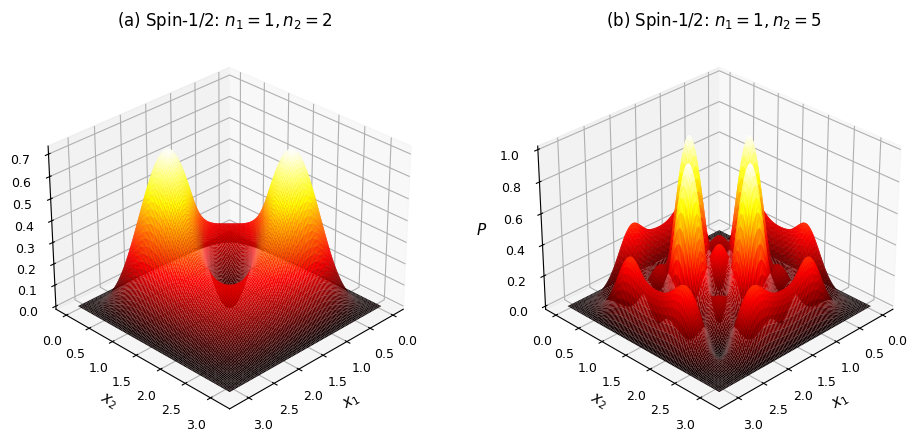

In [47]:
def P2_spin(n1, n2, X1, X2):
    return 0.25 * P2_bosons(n1, n2, X1, X2) + 0.75 * P2_fermions(n1, n2, X1, X2)

# Figura 5: Fermiones con espín (casos específicos)
fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
Z = P2_spin(1, 2, X1, X2)
surf = ax.plot_surface(X1, X2, Z, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11); ax.set_zlabel('$P$', fontsize=11)
ax.set_title('(a) Spin-1/2: $n_1=1, n_2=2$', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
Z2 = P2_spin(1, 5, X1, X2)
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=1, cstride=1)
ax2.set_xlabel('$x_1$', fontsize=11); ax2.set_ylabel('$x_2$', fontsize=11); ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title('(b) Spin-1/2: $n_1=1, n_2=5$', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

### Notas
- Ajuste nmax manualmente para fidelidad en altas temperaturas.
- Las curvas y superficies reproducen cualitativamente las figuras del artículo.
- Todo está en variables adimensionales; no se requiere L o m para las formas.

## Interactive 3D Plots (Plotly)
Plots 3D interactivos que puedes rotar, hacer zoom y explorar con el mouse.

In [48]:
# Figura interactiva: Bosones (n1=n2=1) y (n1=1,n2=5)
x1 = np.linspace(0, PI, 80); x2 = np.linspace(0, PI, 80)
X1, X2 = np.meshgrid(x1, x2)

Z1 = P2_bosons(1, 1, X1, X2)
Z2 = P2_bosons(1, 5, X1, X2)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=('Bosons: n₁=n₂=1', 'Bosons: n₁=1, n₂=5')
)

fig.add_trace(go.Surface(z=Z1, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=1)
fig.add_trace(go.Surface(z=Z2, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=2)

fig.update_layout(
    title_text="Interactive 3D: Bosons",
    height=500,
    scene=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='P'),
    scene2=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='P')
)

# Save as HTML file (open it in browser to interact!)
fig.write_html("interactive_bosons.html")
print("✓ Interactive plot saved to: interactive_bosons.html")
print("  Open this file in your web browser to rotate and explore the 3D plot!")

✓ Interactive plot saved to: interactive_bosons.html
  Open this file in your web browser to rotate and explore the 3D plot!


In [49]:
# Figura interactiva: Fermiones (n1=1,n2=2) y (n1=1,n2=5)
Z1 = P2_fermions(1, 2, X1, X2)
Z2 = P2_fermions(1, 5, X1, X2)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=('Fermions: n₁=1, n₂=2', 'Fermions: n₁=1, n₂=5')
)

fig.add_trace(go.Surface(z=Z1, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=1)
fig.add_trace(go.Surface(z=Z2, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=2)

fig.update_layout(
    title_text="Interactive 3D: Fermions",
    height=500,
    scene=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='P'),
    scene2=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='P')
)

# Save as HTML file (open it in browser to interact!)
fig.write_html("interactive_fermions.html")
print("✓ Interactive plot saved to: interactive_fermions.html")
print("  Open this file in your web browser to rotate and explore the 3D plot!")

✓ Interactive plot saved to: interactive_fermions.html
  Open this file in your web browser to rotate and explore the 3D plot!


In [50]:
# Figura interactiva: P_th termalizada a t=10 (Bosones, Fermiones, Spin-1/2)
t = 10; nmax = choose_nmax(t)
x1 = np.linspace(0, PI, 90); x2 = np.linspace(0, PI, 90)
X1, X2 = np.meshgrid(x1, x2)

print("Computing thermalized densities... (this may take a moment)")
Zb = Pth_two_bosons(X1, X2, t, nmax)
Zf = Pth_two_fermions(X1, X2, t, nmax)
Zs = Pth_two_spin(X1, X2, t, nmax)

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=('Bosons (t=10)', 'Spinless Fermions (t=10)', 'Spin-1/2 Fermions (t=10)')
)

fig.add_trace(go.Surface(z=Zb, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=1)
fig.add_trace(go.Surface(z=Zf, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=2)
fig.add_trace(go.Surface(z=Zs, x=X1, y=X2, colorscale='Hot', showscale=False), row=1, col=3)

fig.update_layout(
    title_text="Interactive 3D: Thermalized Two-Particle Densities",
    height=500,
    scene=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='Pₜₕ'),
    scene2=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='Pₜₕ'),
    scene3=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='Pₜₕ')
)

# Save as HTML file (open it in browser to interact!)
fig.write_html("interactive_thermalized.html")
print("✓ Interactive plot saved to: interactive_thermalized.html")
print("  Open this file in your web browser to rotate and explore the 3D plots!")

Computing thermalized densities... (this may take a moment)
✓ Interactive plot saved to: interactive_thermalized.html
  Open this file in your web browser to rotate and explore the 3D plots!
